In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

## Load the Dataset

In [57]:
df = pd.read_csv('insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Overview 

This dataset was provided as part of a Codecademy portfolio project and appeared to be largely pre-cleaned. I still performed basic data quality checks for missing values, data types, and duplicate records before analysis. 

In [58]:
df.shape

(1338, 7)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [60]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(1)

In [62]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [63]:
df = df.drop_duplicates().copy()

df.duplicated().sum()

np.int64(0)

### Data Cleaning 

The dataset contained no missing values. One duplicate record was identified and removed before moving on to analysis. 

## Descriptive Statistics

I calculated summary statistics to better understand the overall characteristics of the dataset before exploring relationships between variables.

In [64]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [65]:
df.describe(include='object')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


# U.S. Medical Insurance Cost Analysis

This project explores how factors such as age, BMI, smoking status,
and region are associated with medical insurance charges.

In [66]:
avg_age = df.age.mean()
avg_bmi = df.bmi.mean()
avg_children = df.children.mean()
avg_charges = df.charges.mean()

print(f'Average age: {avg_age:.1f} years')
print(f'Average BMI: {avg_bmi:.2f}')
print(f'Average number of children: {avg_children:.2f}')
print(f'Average insurance charge: ${avg_charges:,.2f}') 

Average age: 39.2 years
Average BMI: 30.66
Average number of children: 1.10
Average insurance charge: $13,279.12


### Summary
The dataset has an average age of ~39.2 years, an average BMI of 30.66, and an average of 1.10 children. The average medical insurance charge is ~$13,279.12.

## Distribution of Medical Insurance Charges

Before comparing insurance charges across different groups, I examined the overall distributions of charges to understand their spread, skew, and the presence of unusually high values. 

In [67]:
mean_charge = df.charges.mean()
median_charge = df.charges.median()

print(f'Mean charge: ${mean_charge:,.2f}')
print(f'Median charge: ${median_charge:,.2f}')

Mean charge: $13,279.12
Median charge: $9,386.16


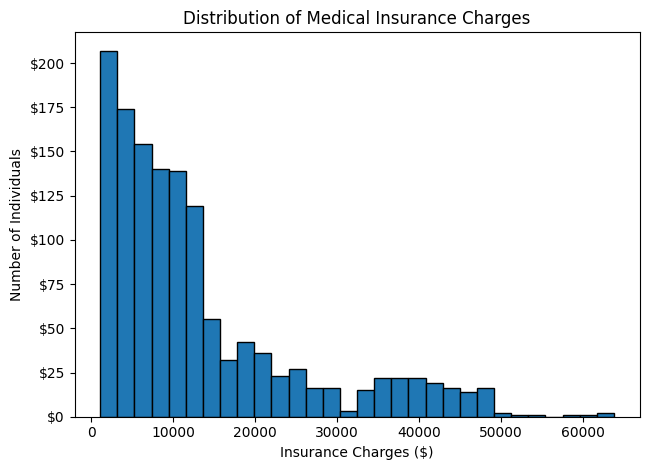

In [68]:
plt.hist(df.charges, bins=30, edgecolor='black')

plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.ylabel('Number of Individuals')
plt.show()

### Findings 
Medical Insurance charges are right-skewed, with most individuals having lower-to-moderate charges and a smaller number of individuals with very high charges. 
The mean charge is $13,279.12, while the median is $9,386.16. Because the mean is noticeably higher than the median, higher-cost observations are pulling the average upward. 
This suggests that average charges alone may not fully represent a typical individual in the dataset, so both mean and median values should be considered in later comparisons. 

## Smoking Status and Insurance Charges

Since the distribution of insurance charges is right-skewed, I compared both the mean and median charges for smokers and non-smokers. This helps determine whether differences in average charges are also reflected in the typical cost within each group.

In [69]:
smoking_summary = df.groupby('smoker').charges.agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
)

smoking_summary

,count,mean,median,std
smoker,,,,
no,1063,8440.660307,7345.72660,5992.973800
yes,274,32050.231832,34456.34845,11541.547176


In [70]:
smoker_mean = smoking_summary.loc['yes', 'mean']
nonsmoker_mean = smoking_summary.loc['no', 'mean']

smoker_median = smoking_summary.loc['yes', 'median']
nonsmoker_median = smoking_summary.loc['no', 'median']

mean_diff = smoker_mean - nonsmoker_mean
mean_percent_diff = (mean_diff / nonsmoker_mean) * 100

median_diff = smoker_median - nonsmoker_median
median_percent_diff = (median_diff / nonsmoker_median) * 100

print(f"Mean charge for smokers: ${smoker_mean:,.2f}")
print(f"Mean charge for non-smokers: ${nonsmoker_mean:,.2f}")
print(f"Mean difference: ${mean_diff:,.2f}")
print(f"Smokers have {mean_percent_diff:.1f}% higher mean charges.")

print()

print(f"Median charge for smokers: ${smoker_median:,.2f}")
print(f"Median charge for non-smokers: ${nonsmoker_median:,.2f}")
print(f"Median difference: ${median_diff:,.2f}")
print(f"Smokers have {median_percent_diff:.1f}% higher median charges.")

Mean charge for smokers: $32,050.23
Mean charge for non-smokers: $8,440.66
Mean difference: $23,609.57
Smokers have 279.7% higher mean charges.

Median charge for smokers: $34,456.35
Median charge for non-smokers: $7,345.73
Median difference: $27,110.62
Smokers have 369.1% higher median charges.


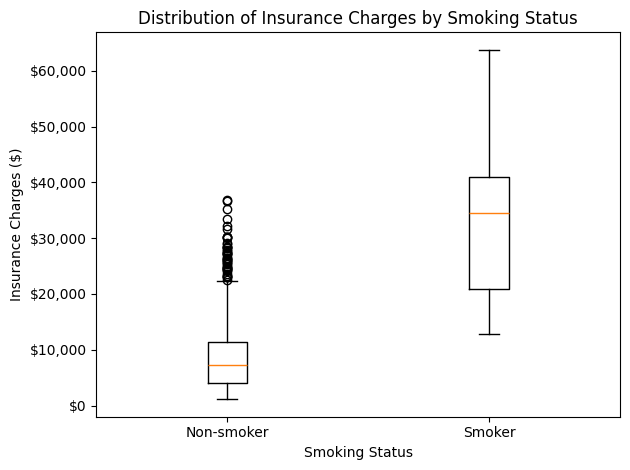

In [71]:
nonsmoker_charges = df[df.smoker == 'no']['charges']
smoker_charges = df[df.smoker == 'yes']['charges']

plt.boxplot(
    [nonsmoker_charges, smoker_charges],
    tick_labels=['Non-smoker', 'Smoker']
)

plt.title('Distribution of Insurance Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

### Finding 
Smoking status is strongly associated with higher insurance charges in this dataset. Smokers had a mean charge of $32,050.23 compared with $8,440.66 for non-smokers, making the mean charge for smokers ~279.7% higher. 
The difference is even larger when comparing medians. The median charge for smokers was $34,456.35 compared with $7,345.73, a difference of ~369.1%.
The boxplot also shows several high-cost outliers among non-smokers. These observations raise the non-smoker mean above the median, which reinforces why examining both measures is useful for this dataset.
Overall, smoking status appears to have a strong association with insurance charges, although this observational analysis does not establish causation. 

## BMI, Smoking Status, and Insurance Charges
Since smoking status showed a strong association with insurance charges, I examined whether the relationship between BMI and charges differs between smokers and non-smokers. 
Rather than analyzing BMI independently, this section compares the relationship within each smoking group. 

In [72]:
smokers = df[df.smoker == 'yes']
non_smokers = df[df.smoker == 'no']

print(f'Smokers: {len(smokers)}')
print(f'Non-smokers: {len(non_smokers)}')

Smokers: 274
Non-smokers: 1063


In [73]:
smoker_bmi_corr = smokers.bmi.corr(smokers.charges)
nonsmoker_bmi_corr = non_smokers.bmi.corr(non_smokers.charges)

print(f'BMI and charge correlation among smokers: {smoker_bmi_corr:.2f}')
print(f'BMI and charge correlation among non smokers: {nonsmoker_bmi_corr:.2f}')

BMI and charge correlation among smokers: 0.81
BMI and charge correlation among non smokers: 0.08


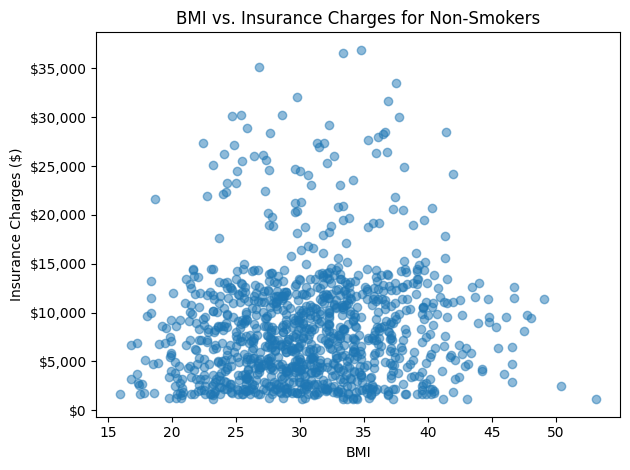

In [74]:
plt.scatter(
    non_smokers.bmi,
    non_smokers.charges,
    alpha=0.5
)

plt.title("BMI vs. Insurance Charges for Non-Smokers")
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

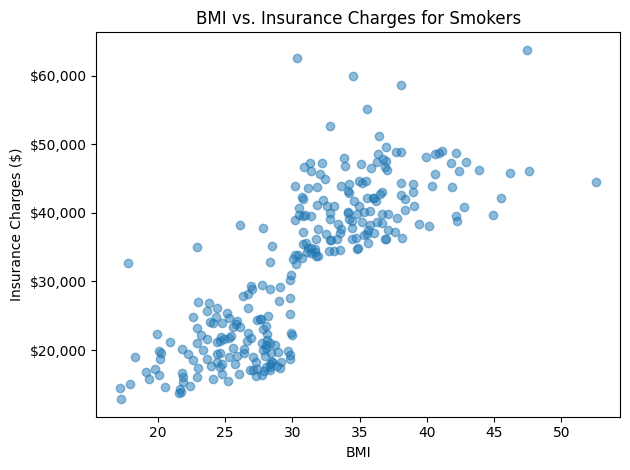

In [75]:
plt.scatter(
    smokers.bmi,
    smokers.charges,
    alpha=0.5
)

plt.title("BMI vs. Insurance Charges for Smokers")
plt.xlabel('BMI')
plt.ylabel('Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

In [76]:
bmi_bins = [0, 18.5, 25, 30, float("inf")]

bmi_labels = [
    "Underweight",
    "Healthy",
    "Overweight",
    "Obesity"
]

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False
)

In [77]:
bmi_smoking_summary = df.groupby(
    ['bmi_category', 'smoker'],
    observed=False
)['charges'].agg(
    count='count',
    mean='mean',
    median='median'
)

bmi_smoking_summary

count          mean       median
bmi_category smoker                                  
Underweight  no         15   5532.992453   3732.62510
             yes         5  18809.824980  15006.57945
Healthy      no        175   7685.656014   6593.50830
             yes        50  19942.223641  19479.90370
Overweight   no        312   8257.961955   7063.91570
             yes        74  22495.874163  21215.43300
Obesity      no        561   8855.531349   8083.91980
             yes       145  41557.989840  40904.19950

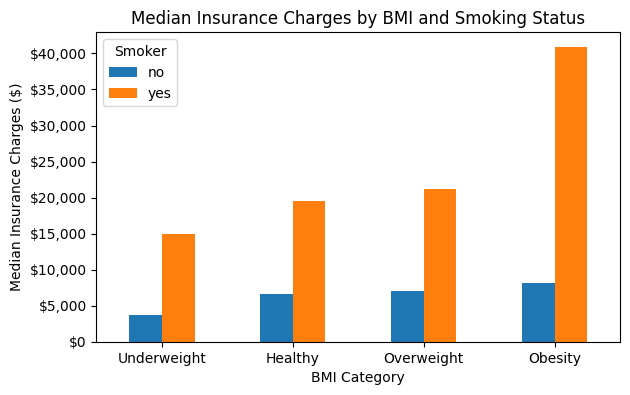

In [78]:
bmi_smoking_median = df.groupby(
    ["bmi_category", "smoker"],
    observed=False
)["charges"].median().unstack()

bmi_smoking_median.plot(kind="bar")

plt.title("Median Insurance Charges by BMI and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Median Insurance Charges ($)")
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.xticks(rotation=0)
plt.legend(title="Smoker")
plt.show()

### Finding 
The relationship between BMI and insurance charges differs substantially by smoking status.
Among smokers, BMI has a strong positive correlation with insurance charges (r = 0.81), while the correlation among non-smokers is very weak (r = 0.08). This suggests that higher BMI is much more strongly associated with higher insurance charges for smokers than for non-smokers.
The grouped median comparison shows the same pattern. Median charges for non-smokers increase gradually across BMI categories, while smokers with obesity have substantially higher median insurance charges than smokers in lower BMI categories.
This indicates that BMI alone does not explain higher insurance costs. Instead, BMI appears to have a much stronger relationship with charges when combined with smoking status.


The underweight smoker group only contains 5 individuals, so results from that category should be interpreted cautiously due to small sample size.

## Age, Smoking Status, and Insurance Charges
After finding that the relationship between BMI and insurance charges differs by smoking status, I examined whether age shows a similar pattern.
This analysis compares the relationship between age and insurance charges separately for smokers and non-smokers.

In [79]:
smoker_age_corr = smokers.age.corr(smokers.charges)
nonsmoker_age_corr = non_smokers.age.corr(non_smokers.charges)

print(f'Age and charge correlation among smokers: {smoker_age_corr:.2f}')
print(f'Age and charge correlation among non-smokers: {nonsmoker_age_corr:.2f}')

Age and charge correlation among smokers: 0.37
Age and charge correlation among non-smokers: 0.63


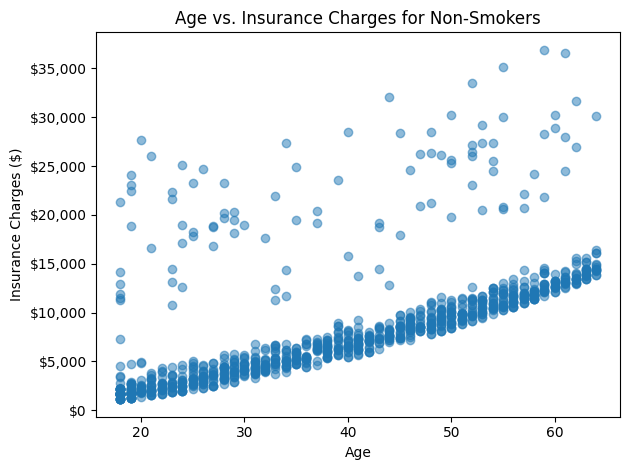

In [80]:
plt.scatter(
    non_smokers.age,
    non_smokers.charges,
    alpha=0.5
)

plt.title('Age vs. Insurance Charges for Non-Smokers')
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

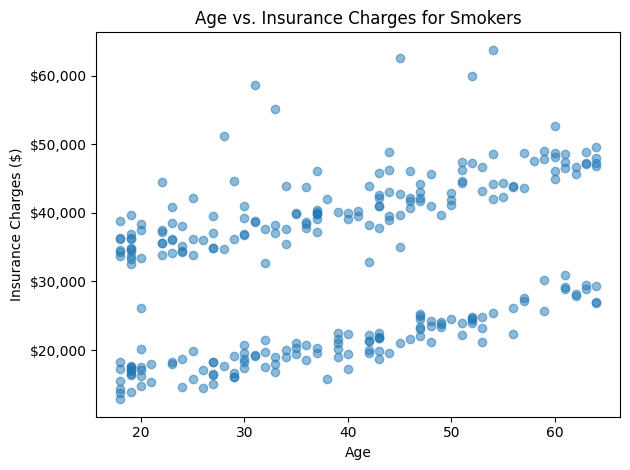

In [81]:
plt.scatter(
    smokers.age,
    smokers.charges,
    alpha=0.5
)

plt.title('Age vs. Insurance Charges for Smokers')
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

In [82]:
age_bins = [17, 30, 45, 60, float('inf')]

age_labels = [
    '18-30',
    '31-45',
    '46-60',
    '61+'
]

df['age_group'] = pd.cut(
    df.age,
    bins=age_bins,
    labels=age_labels
)

In [83]:
age_smoking_summary = df.groupby(
    ['age_group', 'smoker'],
    observed=False
)['charges'].agg(
    count='count',
    mean='mean',
    median='median'
)

age_smoking_summary

count          mean        median
age_group smoker                                   
18-30     no        348   4470.419842   2765.106550
          yes        95  27528.078343  33475.817150
31-45     no        307   7246.170138   6474.013000
          yes        87  31707.164316  37079.372000
46-60     no        339  12188.334036  10965.446000
          yes        70  36451.732069  41668.841550
61+       no         69  15366.613482  13974.455550
          yes        22  38929.615407  46154.658125

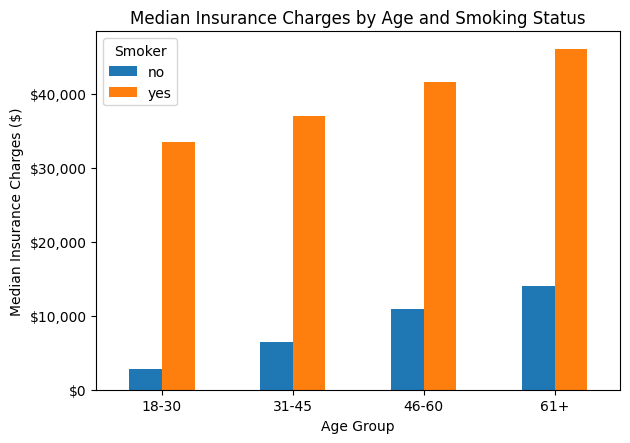

In [84]:
age_smoking_median = df.groupby(
    ["age_group", "smoker"],
    observed=False
)["charges"].median().unstack()
age_smoking_median.plot(kind='bar')

plt.title('Median Insurance Charges by Age and Smoking Status')
plt.xlabel('Age Group')
plt.ylabel('Median Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.xticks(rotation=0)
plt.legend(title='Smoker')
plt.show()

In [85]:
age_smoking_comparison = age_smoking_median.copy()

age_smoking_comparison['difference'] = (
    age_smoking_comparison['yes'] - age_smoking_comparison['no']
)

age_smoking_comparison['percent_higher'] = (
    age_smoking_comparison['difference'] / age_smoking_comparison['no']
) * 100

age_smoking_comparison

smoker,no,yes,difference,percent_higher
age_group,,,,
18-30,2765.10655,33475.817150,30710.710600,1110.651978
31-45,6474.01300,37079.372000,30605.359000,472.741698
46-60,10965.44600,41668.841550,30703.395550,280.001338
61+,13974.45555,46154.658125,32180.202575,230.278757


### Finding
Insurance charges increased with age for both groups, although the relationship was stronger among non-smokers. Age had a moderate positive correlation with charges among non-smokers (r = 0.63), compared with a weaker correlation among smokers (r = 0.37).
Smoking status still remained a major differentiator across every age group. Median charges for smokers were ~$30,000–$32,000 higher than those of non-smokers across the age ranges analyzed.
Although the absolute difference remained relatively consistent, the percentage difference between smokers and non-smokers decreased with age because charges among non-smokers also increased substantially as age increased.
The smoker scatterplot also shows distinct clusters of insurance charges, suggesting that age alone does not explain the variation in costs among smokers. This supports the earlier finding that other factors, such as BMI, may interact with smoking status in their relationship with insurance charges. 

The 61+ smoker group only contains 22 individuals, so results for this group should be interpreted with additional caution due to the smaller sample size.  

## Regional Differences in Insurance Charges 
I examined whether insurance charges vary across regions and whether any apparent regional differences may be influenced by smoking rates within each region.

In [86]:
region_summary = df.groupby('region').charges.agg(
    count='count',
    mean='mean',
    median='median'
)

region_summary

,count,mean,median
region,,,
northeast,324,13406.384516,10057.652025
northwest,324,12450.840844,8976.977250
southeast,364,14735.411438,9294.131950
southwest,325,12346.937377,8798.593000


In [87]:
region_smoking_rate = (
    df.groupby('region').smoker.apply(
        lambda x: (x == 'yes').mean() * 100
    )
)

region_smoking_rate

region
northeast    20.679012
northwest    17.901235
southeast    25.000000
southwest    17.846154
Name: smoker, dtype: float64

In [88]:
region_comparison= region_summary.copy()

region_comparison['smoking_rate'] = region_smoking_rate

region_comparison

,count,mean,median,smoking_rate
region,,,,
northeast,324,13406.384516,10057.652025,20.679012
northwest,324,12450.840844,8976.977250,17.901235
southeast,364,14735.411438,9294.131950,25.000000
southwest,325,12346.937377,8798.593000,17.846154


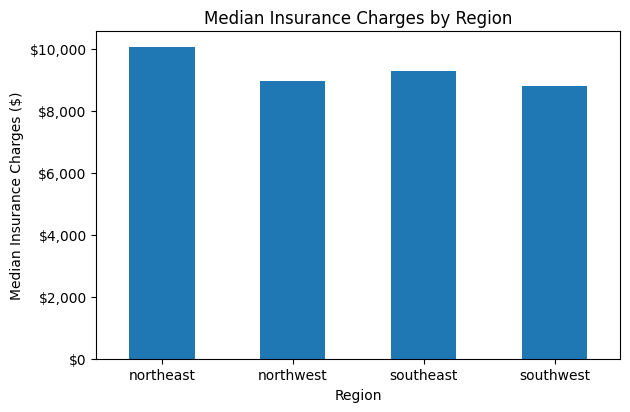

In [89]:
region_summary['median'].plot(kind='bar')

plt.title('Median Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Median Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

In [90]:
region_smoking_summary = df.groupby(
    ['region', 'smoker']
)['charges'].agg(
    count='count',
    mean='mean',
    median='median' 
)

region_smoking_summary

count          mean        median
region    smoker                                   
northeast no        257   9165.531672   8342.908750
          yes        67  29673.536473  28101.333050
northwest no        266   8582.467101   7259.232050
          yes        58  30192.003182  27488.996475
southeast no        273   8032.216309   6652.528800
          yes        91  34844.996824  37484.449300
southwest no        267   8019.284513   7348.142000
          yes        58  32269.063494  35165.256500

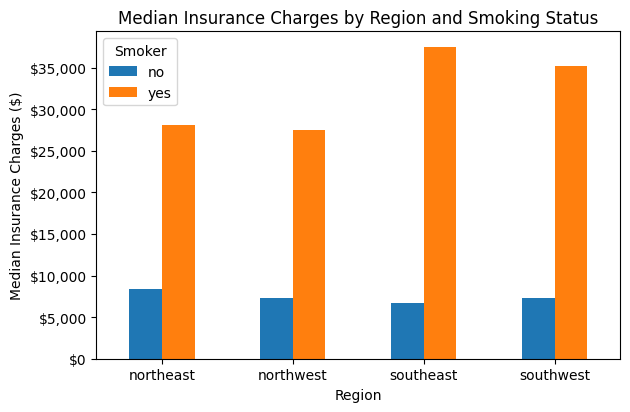

In [91]:
region_smoking_median = df.groupby(
    ['region', 'smoker']
)['charges'].median().unstack()

region_smoking_median.plot(kind='bar')

plt.title('Median Insurance Charges by Region and Smoking Status')
plt.xlabel('Region')
plt.ylabel('Median Insurance Charges ($)')
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.xticks(rotation=0)
plt.legend(title='Smoker')
plt.show()

### Finding
Overall insurance charges varied across regions. The Northeast had the highest overall median charge at ~$10,058, while the Southwest had the lowest at ~$8,799.
The Southeast had the highest smoking rate at 25% and also had the highest mean insurance charge. This suggetss that differences in smoking may contribute to some of the variation observed in overall regional costs.
However, smoking rates alone do not explain the regional differences. When smokers and non-smokers were analyzed separately, non-smoker median charges were relatively similar across regions, ranging from ~$6,653 to $8,343. In contrast, smoker median charges varied much more substantially, ranging from ~$27,489 in the Northwest to $37,484 in the Southeast.
These results suggest that region may be associated with insurance charges through differences in population characteristics, but additional factors would need to be considered. 

## Characteristics of the Highest-Cost Individuals 
To better understand which characteristics are associated with the highest insurance costs, I examined individuals whose charges fell within the top 10% of the dataset. 
I compared this high-cost group with the overall dataset across smoking status, age, BMI, and region. 

In [92]:
high_cost_threshold = df.charges.quantile(0.90)

high_cost = df[df.charges >= high_cost_threshold].copy()

print(f'Top 10% charge threshold: ${high_cost_threshold:,.2f}')
print(f'Number of individuals in top 10%: {len(high_cost)}')

Top 10% charge threshold: $34,832.74
Number of individuals in top 10%: 134


In [93]:
high_cost[['age','bmi','children','charges']].describe()

,age,bmi,children,charges
count,134.000000,134.000000,134.000000,134.000000
mean,41.783582,35.652500,1.223881,42378.686097
std,13.528784,4.483315,1.128188,5497.057318
min,18.000000,22.895000,0.000000,34838.873000
25%,31.000000,32.775000,0.000000,38298.203625
50%,43.000000,35.300000,1.000000,41379.381875
75%,53.000000,37.775000,2.000000,46050.934500
max,64.000000,52.580000,4.000000,63770.428010


In [94]:
high_cost_smoking = (
    high_cost.smoker
    .value_counts(normalize=True)
    .mul(100)
)

high_cost_smoking

smoker
yes    97.761194
no      2.238806
Name: proportion, dtype: float64

In [95]:
overall_smoking_rate = (
    df["smoker"]
    .value_counts(normalize=True)
    .mul(100)
)

overall_smoking_rate

smoker
no     79.506358
yes    20.493642
Name: proportion, dtype: float64

In [96]:
high_cost_bmi = (
    high_cost["bmi_category"]
    .value_counts(normalize=True)
    .mul(100)
)

high_cost_bmi

bmi_category
Obesity        96.268657
Overweight      2.985075
Healthy         0.746269
Underweight     0.000000
Name: proportion, dtype: float64

In [97]:
high_cost_age = (
    high_cost["age_group"]
    .value_counts(normalize=True)
    .mul(100)
)

high_cost_age

age_group
31-45    34.328358
46-60    31.343284
18-30    24.626866
61+       9.701493
Name: proportion, dtype: float64

In [98]:
high_cost_region = (
    high_cost["region"]
    .value_counts(normalize=True)
    .mul(100)
)

high_cost_region

region
southeast    41.044776
southwest    23.880597
northeast    20.149254
northwest    14.925373
Name: proportion, dtype: float64

In [99]:
overall_obesity_rate = (
    (df["bmi_category"] == "Obesity").mean() * 100
)

high_cost_obesity_rate = (
    (high_cost["bmi_category"] == "Obesity").mean() * 100
)

overall_southeast_rate = (
    (df["region"] == "southeast").mean() * 100
)

high_cost_southeast_rate = (
    (high_cost["region"] == "southeast").mean() * 100
)

overall_smoker_rate = (
    (df["smoker"] == "yes").mean() * 100
)

high_cost_smoker_rate = (
    (high_cost["smoker"] == "yes").mean() * 100
)

high_cost_comparison = pd.DataFrame({
    "Overall Dataset": [
        overall_smoker_rate,
        overall_obesity_rate,
        overall_southeast_rate
    ],
    "Top 10% Costs": [
        high_cost_smoker_rate,
        high_cost_obesity_rate,
        high_cost_southeast_rate
    ]
}, index=[
    "Smoker",
    "Obesity",
    "Southeast"
])

high_cost_comparison.round(1)

,Overall Dataset,Top 10% Costs
Smoker,20.5,97.8
Obesity,52.8,96.3
Southeast,27.2,41.0


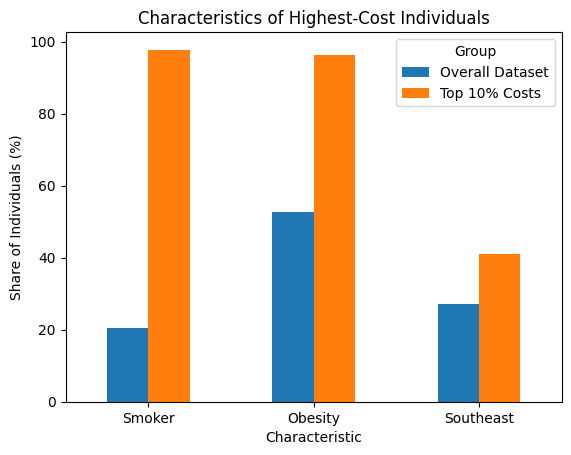

In [100]:
high_cost_comparison.plot(kind="bar")

plt.title("Characteristics of Highest-Cost Individuals")
plt.xlabel("Characteristic")
plt.ylabel("Share of Individuals (%)")
plt.xticks(rotation=0)
plt.legend(title="Group")
plt.show()

### Finding

The top 10% of individuals had insurance charges of at least $34,832.74 and looked very different from the dataset overall.
Smoking status stood out the most. ~97.8% of the highest-cost group were smokers, compared with only ~20.5% of the full dataset.
BMI showed a similar pattern. ~96.3% of the highest-cost group fell into the obesity category, compared with ~52.8% of the overall dataset. The average BMI in the high-cost group was 35.65, compared with 30.66 overall.
Age did not stand out as strongly. The average age in the high-cost group was ~41.8 years, compared with ~39.2 years overall, and high-cost cases were spread across multiple age groups.
The Southeast was also more common in the high-cost group, making up ~41.0% of those individuals compared with ~27.2% of the full dataset.
Overall, the results support the earlier findings that smoking status, especially when combined with higher BMI, is strongly associated with higher insurance charges in this dataset.
These patterns show associations within the data and do not prove that any one factor directly causes higher insurance charges.

## Key Findings

- Insurance charges were right-skewed, with a mean of $13,279.12 and a median of $9,386.16. This showed that a smaller number of high-cost cases were pulling the average upward.

- Smoking status showed the clearest association with higher insurance charges in this analysis. Smokers had mean charges ~279.7% higher and median charges ~369.1% higher than non-smokers.

- BMI had a very different relationship with charges depending on smoking status. Among smokers, BMI and charges had a strong positive correlation of 0.81, compared with only 0.08 among non-smokers.

- Age was associated with higher charges for both smokers and non-smokers, but smoking remained a major cost difference across every age group. The median gap between smokers and non-smokers stayed around $30,000–$32,000 across the age ranges analyzed.

- Regional differences were present, but region alone did not explain insurance costs. The Southeast had the highest smoking rate and was overrepresented among high-cost individuals, while smoker charges also varied noticeably across regions.

- The highest-cost 10% of individuals were especially distinct. ~97.8% were smokers and ~96.3% fell into the obesity BMI category, compared with ~20.5% smokers and ~52.8% in the obesity category across the full dataset.

Overall, smoking status stood out as the factor most strongly associated with higher insurance charges, especially when combined with higher BMI.

## Limitations

- This dataset is relatively small, with 1,337 records after removing one duplicate, so the results may not represent the broader U.S. population.

- The data includes only a limited number of variables. Other factors that can affect insurance charges, such as medical history, specific diagnoses, coverage level, occupation, or healthcare usage, are not included.

- Some subgroups are much smaller than others. For example, the underweight smoker group had only 5 individuals, and the 61+ smoker group had only 22. Results for these smaller groups should be interpreted carefully.

- The analysis shows associations between variables, not causation. For example, smoking status and higher BMI were strongly associated with higher charges, but this dataset alone cannot prove that either factor directly caused the higher costs.

- Regional differences may reflect other characteristics that are not captured in the dataset, so the results should not be interpreted as evidence that location itself causes higher insurance charges.